In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Generar 10000 datos sintéticos
# Relación base: insulina ≈ 0.8 * azucar + 20 (con algo de ruido)
np.random.seed(42)
azucar = np.random.uniform(50, 400, 10000).tolist()       # mg/dL de azúcar en sangre
insulina = [0.8 * x + 20 + np.random.normal(0, 15) for x in azucar]  # unidades de insulina producida

# Datos de la línea recta deseada: y = a * x + b
a_deseado = 0 #theta1 o b
b_deseado = 0 #theta0 o a

# Rangos para los coeficientes
rango_a = np.arange(-1, 2.1, 0.1)  # Rango para el término independiente (a)
rango_b = np.arange(-500, 501, 10)  # Rango para el coeficiente de x (b)

print(rango_a)
print("#")
print(rango_b)

[-1.00000000e+00 -9.00000000e-01 -8.00000000e-01 -7.00000000e-01
 -6.00000000e-01 -5.00000000e-01 -4.00000000e-01 -3.00000000e-01
 -2.00000000e-01 -1.00000000e-01 -2.22044605e-16  1.00000000e-01
  2.00000000e-01  3.00000000e-01  4.00000000e-01  5.00000000e-01
  6.00000000e-01  7.00000000e-01  8.00000000e-01  9.00000000e-01
  1.00000000e+00  1.10000000e+00  1.20000000e+00  1.30000000e+00
  1.40000000e+00  1.50000000e+00  1.60000000e+00  1.70000000e+00
  1.80000000e+00  1.90000000e+00  2.00000000e+00]
#
[-500 -490 -480 -470 -460 -450 -440 -430 -420 -410 -400 -390 -380 -370
 -360 -350 -340 -330 -320 -310 -300 -290 -280 -270 -260 -250 -240 -230
 -220 -210 -200 -190 -180 -170 -160 -150 -140 -130 -120 -110 -100  -90
  -80  -70  -60  -50  -40  -30  -20  -10    0   10   20   30   40   50
   60   70   80   90  100  110  120  130  140  150  160  170  180  190
  200  210  220  230  240  250  260  270  280  290  300  310  320  330
  340  350  360  370  380  390  400  410  420  430  440  450  460  

In [11]:
mejor_error = float('inf')
mejor_a = None
mejor_b = None

# Bucle para probar diferentes combinaciones de coeficientes
for b in rango_b:
    for a in rango_a:
        error_acumulado = 0
        for indice, x in enumerate(azucar):

          # Calcular valores de y predichos por la ecuación
          y_pred = a * x + b

          # error_actual = y_pred - precios[indice]
          error_actual = (y_pred - insulina[indice])**2
          # print(x, precios[indice])

          error_acumulado = error_acumulado + error_actual

        # Actualizar los mejores coeficientes si encontramos un mejor ajuste
        error_acumulado = error_acumulado * (1 /(2 * len(azucar)))
        if error_acumulado < mejor_error:
            mejor_error = error_acumulado
            mejor_a = a
            mejor_b = b

print("Coeficiente de x (a) más cercano:", mejor_a)
print("Término independiente (b) más cercano:", mejor_b)

Coeficiente de x (a) más cercano: 0.7999999999999996
Término independiente (b) más cercano: 20


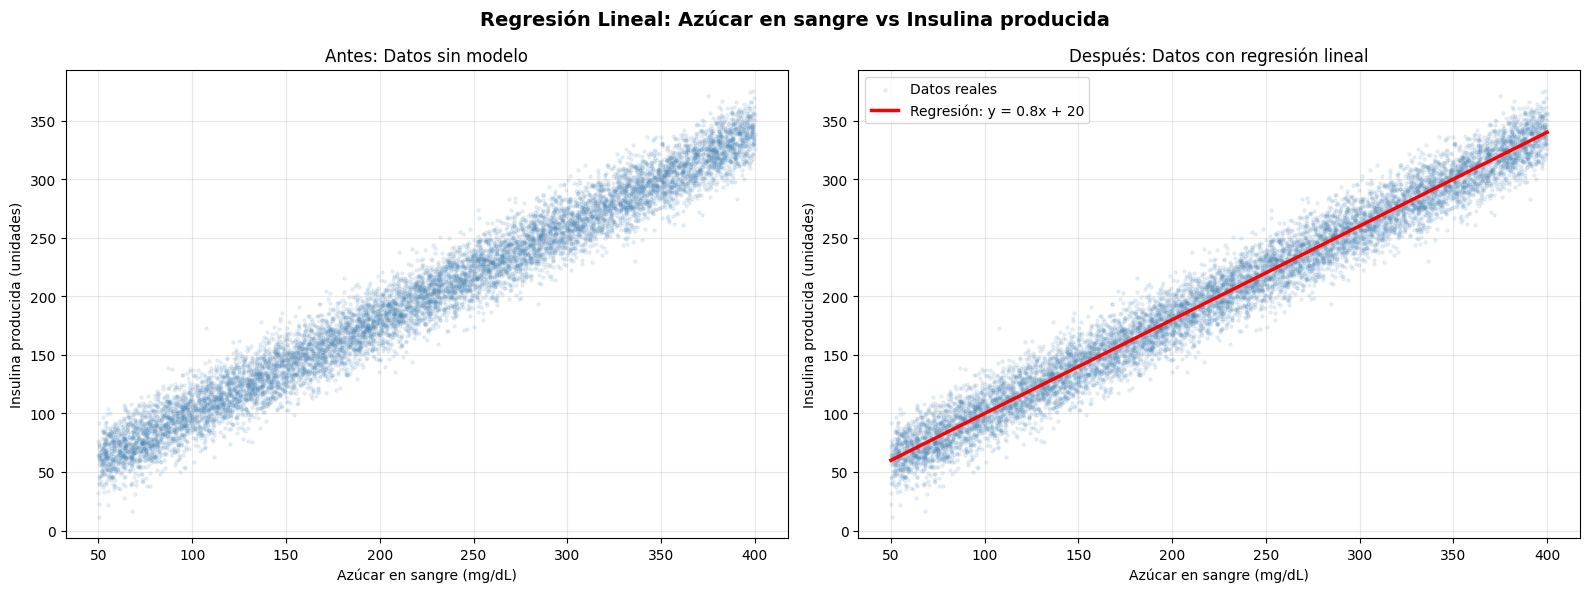

In [12]:
azucar_np = np.array(azucar)
insulina_np = np.array(insulina)

x_linea = np.linspace(50, 400, 200)
y_linea = mejor_a * x_linea + mejor_b

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Regresión Lineal: Azúcar en sangre vs Insulina producida", fontsize=14, fontweight='bold')

# Antes: solo los datos crudos
ax1.scatter(azucar_np, insulina_np, alpha=0.1, s=5, color='steelblue')
ax1.set_title("Antes: Datos sin modelo")
ax1.set_xlabel("Azúcar en sangre (mg/dL)")
ax1.set_ylabel("Insulina producida (unidades)")
ax1.grid(True, alpha=0.3)

# Después: datos + línea de regresión
ax2.scatter(azucar_np, insulina_np, alpha=0.1, s=5, color='steelblue', label='Datos reales')
ax2.plot(x_linea, y_linea, color='red', linewidth=2.5, label=f'Regresión: y = {mejor_a:.1f}x + {mejor_b}')
ax2.set_title("Después: Datos con regresión lineal")
ax2.set_xlabel("Azúcar en sangre (mg/dL)")
ax2.set_ylabel("Insulina producida (unidades)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()